# Data load

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df=pd.read_csv('/content/anime.csv')

In [ ]:
df

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [ ]:
df.sample(4)

,anime_id,name,genre,type,episodes,rating,members
3911,557,Koutetsu Tenshi Kurumi Encore,"Comedy, Historical, Romance, Sci-Fi, Shounen",OVA,4,6.85,4734
3863,2814,Dondon Domeru to Ron,"Comedy, Kids",TV,52,6.86,531
8299,18071,Chalk-iro no People,"Romance, Seinen",OVA,1,5.29,92
1047,11743,Toaru Majutsu no Index: Endymion no Kiseki,"Action, Magic, Sci-Fi, Super Power",Movie,1,7.71,54873


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


# Data Cleaning

In [ ]:
df.isna().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


In [ ]:
df['genre'].fillna(df['genre'].mode()[0],inplace=True)

/tmp/ipykernel_1378/2221661984.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['genre'].fillna(df['genre'].mode()[0],inplace=True)


In [ ]:
df['type'].fillna(df['type'].mode()[0],inplace=True)

/tmp/ipykernel_1378/1828210288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['type'].fillna(df['type'].mode()[0],inplace=True)


In [ ]:
df['rating'].fillna(df['rating'].mean(),inplace=True)

/tmp/ipykernel_1378/3424798236.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].mean(),inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,anime_id,rating,members
count,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.017096,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.900000,2.250000e+02
50%,10260.500000,6.550000,1.550000e+03
75%,24794.500000,7.170000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


# EDA

In [ ]:
df['type'].value_counts()

,count
type,
TV,3812
OVA,3311
Movie,2348
Special,1676
ONA,659
Music,488


In [ ]:
from wordcloud import WordCloud

In [ ]:
text=" ".join(df['name'])

In [ ]:
text

'Kimi no Na wa. Fullmetal Alchemist: Brotherhood Gintama° Steins;Gate Gintama&#039; Haikyuu!!: Karasuno Koukou VS Shiratorizawa Gakuen Koukou Hunter x Hunter (2011) Ginga Eiyuu Densetsu Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare Gintama&#039;: Enchousen Clannad: After Story Koe no Katachi Gintama Code Geass: Hangyaku no Lelouch R2 Haikyuu!! Second Season Sen to Chihiro no Kamikakushi Shigatsu wa Kimi no Uso Mushishi Zoku Shou 2nd Season Ookami Kodomo no Ame to Yuki Code Geass: Hangyaku no Lelouch Hajime no Ippo Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen Cowboy Bebop One Punch Man Mononoke Hime Suzumiya Haruhi no Shoushitsu Monogatari Series: Second Season Mushishi Zoku Shou Mushishi Tengen Toppa Gurren Lagann Great Teacher Onizuka Natsume Yuujinchou Go Hajime no Ippo: New Challenger Mushishi Zoku Shou: Suzu no Shizuku Natsume Yuujinchou Shi Howl no Ugoku Shiro Fate/Zero 2nd Season Kizumonogatari II: Nekketsu-hen Monster Bakuman. 3rd Season Death Note Gintama°: Aizom

In [ ]:
wcloud=WordCloud(background_color='white',width=800,height=500).generate(text)

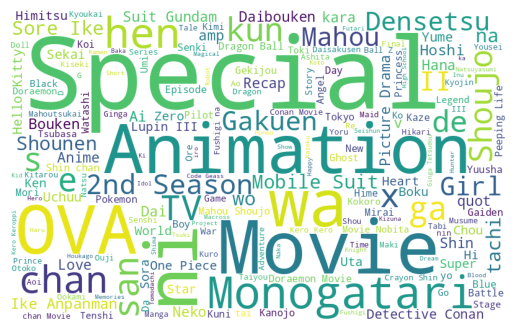

In [ ]:
plt.imshow(wcloud)
plt.axis('off')
plt.show()

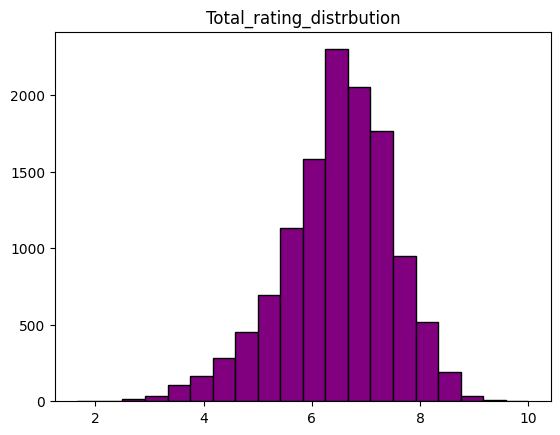

In [ ]:
plt.hist(df['rating'],bins=20,color='purple',edgecolor='black')
plt.title("Total_rating_distrbution")
plt.show()

In [ ]:
type_counts=df['type'].value_counts()


In [ ]:
fig1=px.pie(df,names='type',title='Total type')
fig1.show()

In [ ]:
fig4=px.sunburst(df,path=["type"],values='rating')
fig4.show()

In [ ]:
df.corr(numeric_only=True)

,anime_id,rating,members
anime_id,1.000000,-0.277152,-0.080071
rating,-0.277152,1.000000,0.387523
members,-0.080071,0.387523,1.000000


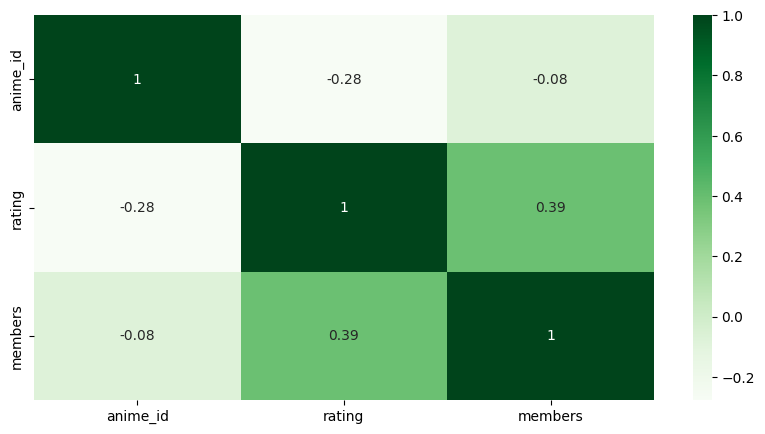

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Greens")
plt.show()

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.1 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import  ProfileReport

In [ ]:
EDA_Report=ProfileReport(df,title='anmia_EDA',explorative=True)

In [ ]:
EDA_Report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00,  9.14it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]